# 02. Advanced Mosquito Trajectory Analysis
Advanced research-driven metrics: Aggregate Stats, Screw Motion, Chirality, and Goal Anchors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.auto import tqdm
from sklearn.cluster import KMeans

DATA_DIR = '../data/open/train/'
DT = 0.040
sns.set_theme(style='whitegrid')

c:\Repo\dacon-mosquito-trajectory\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [2]:
train_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))
def load_and_normalize(file_list, limit=1000):
    all_data = []
    for f in tqdm(file_list[:limit]):
        df = pd.read_csv(f)
        df['ID'] = os.path.basename(f).split('.')[0]
        origin = df.iloc[-1][['x', 'y', 'z']].values
        df[['x', 'y', 'z']] -= origin
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

df = load_and_normalize(train_files, limit=2000)

def add_kinematics(df):
    df = df.copy()
    for col in ['x', 'y', 'z']: df[col] = df[col].astype(float)
    df[['vx', 'vy', 'vz']] = df.groupby('ID')[['x', 'y', 'z']].diff() / DT
    v_vals = df[['vx', 'vy', 'vz']].values.astype(float)
    df['speed'] = np.sum(v_vals**2, axis=1)**0.5
    df[['ax', 'ay', 'az']] = df.groupby('ID')[['vx', 'vy', 'vz']].diff() / DT
    a_vals = df[['ax', 'ay', 'az']].values.astype(float)
    cross = np.cross(v_vals, a_vals)
    cross_mag = np.sum(cross**2, axis=1)**0.5
    df['curvature'] = cross_mag / (df['speed']**3 + 1e-6)
    return df.dropna()

df_kin = add_kinematics(df)

100%|██████████| 2000/2000 [00:09<00:00, 202.92it/s]


## 2. Per-ID Aggregation

Text(0.5, 1.0, 'Straightness Distribution')

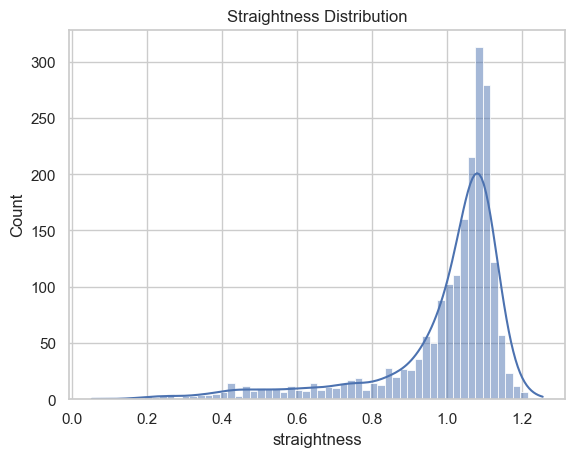

In [3]:
def aggregate_per_id(df_kin, df_norm):
    agg = df_kin.groupby('ID').agg({'speed': ['mean', 'max'], 'curvature': 'mean'})
    agg.columns = ['_'.join(col) for col in agg.columns.values]
    path_len = df_kin.groupby('ID')['speed'].sum() * DT
    def get_disp(group):
        p_start = group.iloc[0][['x', 'y', 'z']].values.astype(float)
        p_end = group.iloc[-1][['x', 'y', 'z']].values.astype(float)
        return np.sum((p_end - p_start)**2)**0.5
    disp = df_norm.groupby('ID').apply(get_disp)
    agg['straightness'] = disp / (path_len + 1e-6)
    return agg

df_id = aggregate_per_id(df_kin, df)
sns.histplot(df_id['straightness'], kde=True).set_title('Straightness Distribution')

## 3. Screw Motion & Goal Anchors

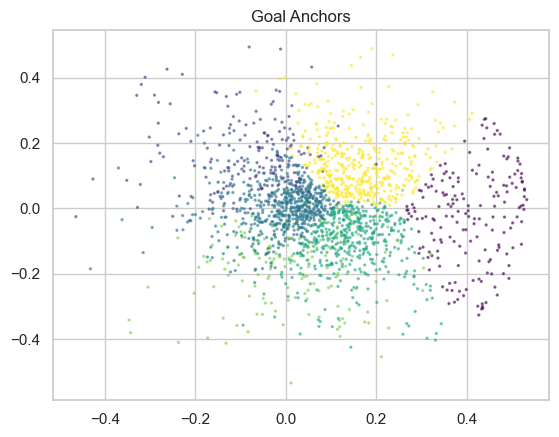

In [4]:
disps = np.array(df.groupby('ID').apply(lambda g: (g.iloc[-1][['x','y','z']].values - g.iloc[0][['x','y','z']].values).astype(float)).tolist())
kmeans = KMeans(n_clusters=6, n_init='auto', random_state=42).fit(disps)
plt.scatter(disps[:,0], disps[:,1], c=kmeans.labels_, cmap='viridis', s=2, alpha=0.5)
plt.title('Goal Anchors'); plt.show()